# CNN Training Pipeline: CIFAR-10 Classification

This notebook demonstrates the complete training pipeline for a Convolutional Neural Network (CNN) on the CIFAR-10 dataset. We will cover:

1. **Data Loading** - Using PyTorch's DataLoader with CIFAR-10
2. **Key CNN Concepts:**
   - (i) Kernels (filters)
   - (ii) Padding and Stride
   - (iii) 1x1 Convolutions
   - (iv) Global Average Pooling
3. **Model Architecture**
4. **Training Loop**
5. **Evaluation**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## 1. Data Loading with CIFAR-10

CIFAR-10 consists of 60,000 32x32 color images in 10 classes:
- airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- 50,000 training images and 10,000 test images

### Key Components:
- **`transforms`**: Preprocessing pipeline (normalization, augmentation)
- **`DataLoader`**: Batches data, shuffles, and enables parallel loading

In [ ]:
# Define transforms for the training and test sets
# CIFAR-10 images are 32x32 RGB images

# Training transforms with data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # Randomly flip images horizontally
    transforms.RandomCrop(32, padding=4),        # Random crop with padding
    transforms.ToTensor(),                       # Convert PIL image to tensor [0, 1]
    transforms.Normalize(                        # Normalize to [-1, 1] range
        mean=(0.4914, 0.4822, 0.4465),          # CIFAR-10 channel means
        std=(0.2470, 0.2435, 0.2616)            # CIFAR-10 channel stds
    )
])

# Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [ ]:
# Download and load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

# Class names for CIFAR-10
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:05<00:00, 31.4MB/s]


Training samples: 50000
Test samples: 10000


In [ ]:
# Create DataLoaders
# DataLoader handles batching, shuffling, and parallel data loading

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # Shuffle training data each epoch
    num_workers=2,          # Parallel data loading
    pin_memory=True         # Faster data transfer to GPU
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # No need to shuffle test data
    num_workers=2,
    pin_memory=True
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 391
Number of test batches: 79


In [ ]:
# Accessing data from the DataLoader
# Get one batch to examine the data structure

images, labels = next(iter(train_loader))

print(f"Batch shape: {images.shape}")   # [batch_size, channels, height, width]
print(f"Labels shape: {labels.shape}")  # [batch_size]
print(f"Image dtype: {images.dtype}")
print(f"Label dtype: {labels.dtype}")

Batch shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


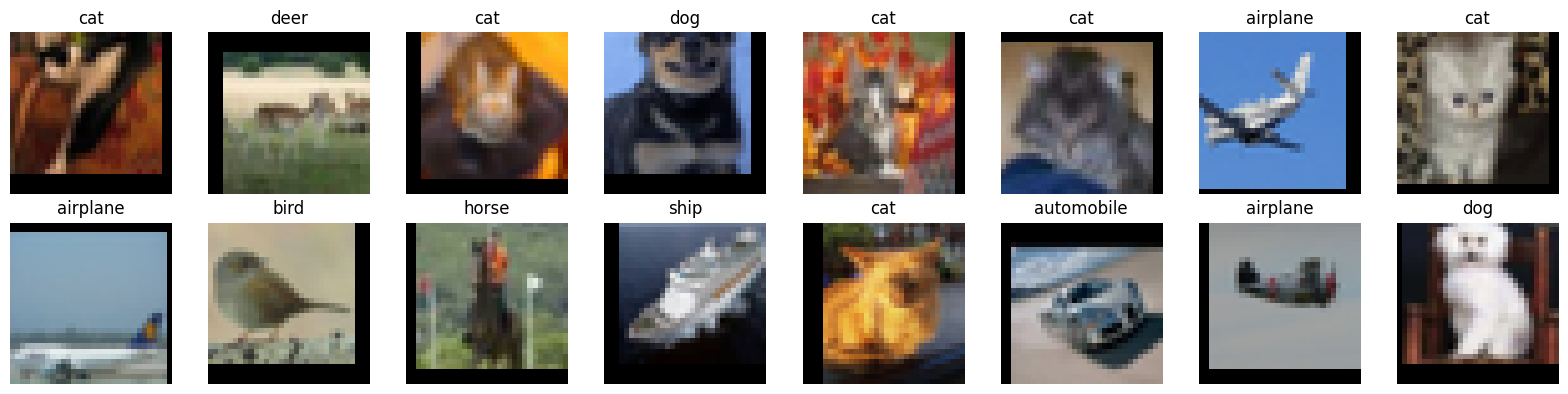

In [ ]:
# Visualize some training images
def imshow(img, title=None):
    """Display a tensor image (unnormalize first)"""
    # Unnormalize
    img = img.numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = std[:, None, None] * img + mean[:, None, None]
    img = np.clip(img, 0, 1)

    plt.imshow(np.transpose(img, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

# Show a grid of images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(images[i], classes[labels[i]])
plt.tight_layout()
plt.show()

---
## 2. Key CNN Concepts

Before building our model, let's understand the fundamental building blocks of CNNs.

### (i) Kernels (Filters)

A **kernel** (or filter) is a small matrix that slides across the input image to detect features.

- Kernels learn to detect patterns: edges, textures, shapes, etc.
- Early layers detect simple features; deeper layers detect complex patterns
- Kernel size is typically 3x3, 5x5, or 7x7

**Convolution operation**: The kernel slides across the input, computing element-wise multiplication and summing the results at each position.

Let's visualize how convolution works step-by-step:

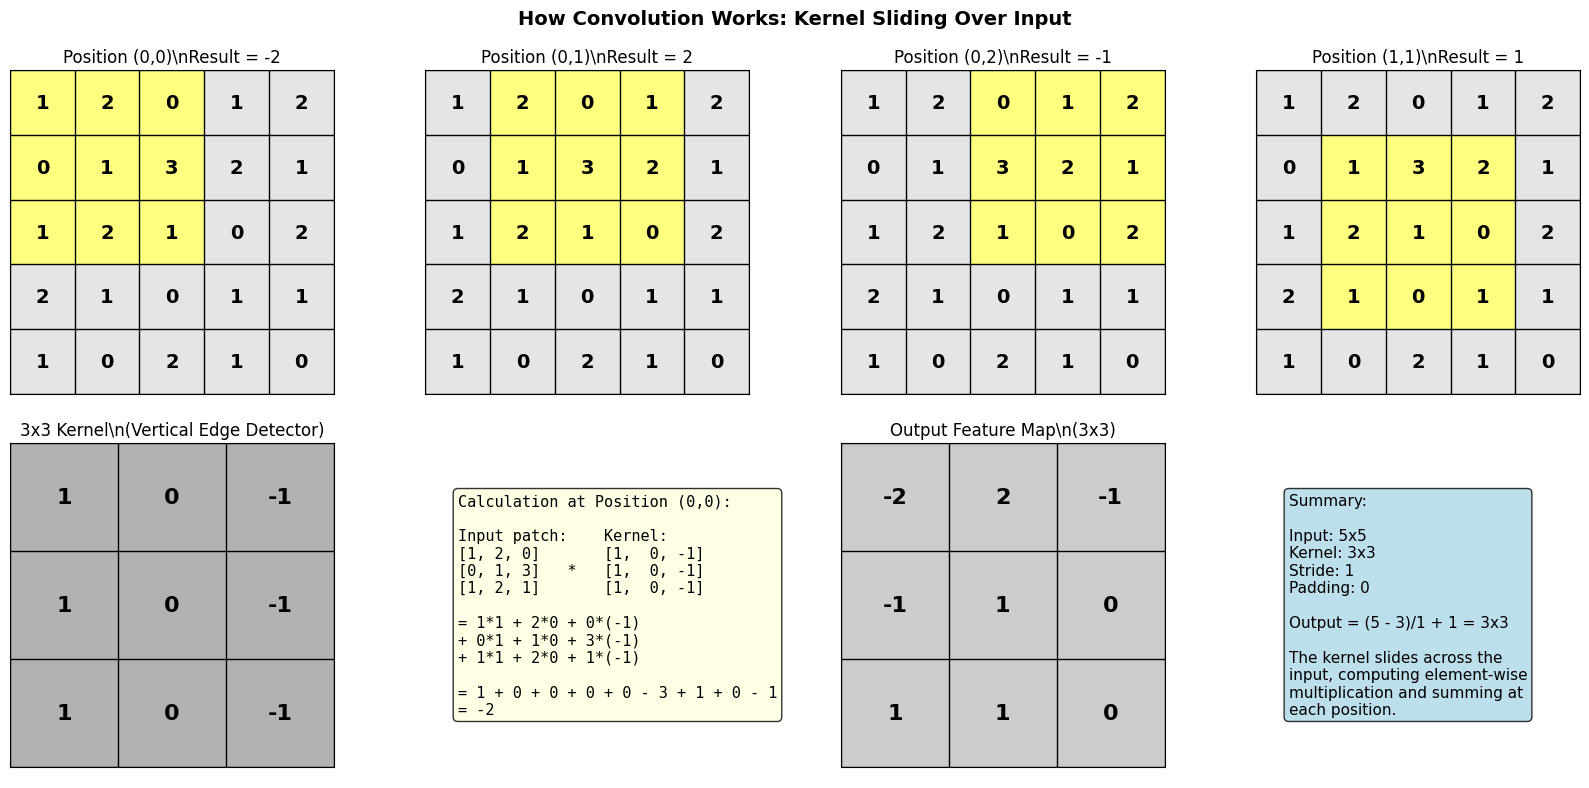

In [ ]:
# Visual Diagram: How Convolution Works Step-by-Step
# This shows a 3x3 kernel sliding over a 5x5 input

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Create a simple 5x5 input matrix
input_matrix = np.array([
    [1, 2, 0, 1, 2],
    [0, 1, 3, 2, 1],
    [1, 2, 1, 0, 2],
    [2, 1, 0, 1, 1],
    [1, 0, 2, 1, 0]
])

# Simple 3x3 kernel
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# Calculate output size: (5 - 3 + 0) / 1 + 1 = 3
output_matrix = np.zeros((3, 3))

# Show the convolution at different positions
positions = [(0, 0), (0, 1), (0, 2), (1, 1)]
titles = ['Position (0,0)', 'Position (0,1)', 'Position (0,2)', 'Position (1,1)']

for idx, (i, j) in enumerate(positions):
    ax = axes[0, idx]

    # Create colored version showing the receptive field
    display = np.zeros((5, 5, 3))
    display[:, :, 0] = 0.9  # Light background
    display[:, :, 1] = 0.9
    display[:, :, 2] = 0.9

    # Highlight the receptive field in yellow
    display[i:i+3, j:j+3, 0] = 1.0
    display[i:i+3, j:j+3, 1] = 1.0
    display[i:i+3, j:j+3, 2] = 0.5

    ax.imshow(display, extent=[-0.5, 4.5, 4.5, -0.5])

    # Add grid and values
    for ii in range(5):
        for jj in range(5):
            ax.text(jj, ii, str(input_matrix[ii, jj]), ha='center', va='center', fontsize=14, fontweight='bold')

    # Add grid lines
    for line in range(6):
        ax.axhline(y=line-0.5, color='black', linewidth=1)
        ax.axvline(x=line-0.5, color='black', linewidth=1)

    # Calculate the convolution result at this position
    receptive_field = input_matrix[i:i+3, j:j+3]
    result = np.sum(receptive_field * kernel)
    output_matrix[i, j] = result

    ax.set_title(f'{titles[idx]}\\nResult = {result}', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Show the kernel
axes[1, 0].imshow(np.ones((3, 3, 3)) * 0.7)
for ii in range(3):
    for jj in range(3):
        axes[1, 0].text(jj, ii, str(kernel[ii, jj]), ha='center', va='center', fontsize=16, fontweight='bold')
for line in range(4):
    axes[1, 0].axhline(y=line-0.5, color='black', linewidth=1)
    axes[1, 0].axvline(x=line-0.5, color='black', linewidth=1)
axes[1, 0].set_title('3x3 Kernel\\n(Vertical Edge Detector)', fontsize=12)
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])

# Show the calculation for one position
axes[1, 1].axis('off')
calc_text = """Calculation at Position (0,0):

Input patch:    Kernel:
[1, 2, 0]       [1,  0, -1]
[0, 1, 3]   *   [1,  0, -1]
[1, 2, 1]       [1,  0, -1]

= 1*1 + 2*0 + 0*(-1)
+ 0*1 + 1*0 + 3*(-1)
+ 1*1 + 2*0 + 1*(-1)

= 1 + 0 + 0 + 0 + 0 - 3 + 1 + 0 - 1
= -2"""
axes[1, 1].text(0.1, 0.5, calc_text, fontsize=11, family='monospace', va='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Show the output matrix
axes[1, 2].imshow(np.ones((3, 3, 3)) * 0.8)
# Calculate full output
for ii in range(3):
    for jj in range(3):
        val = np.sum(input_matrix[ii:ii+3, jj:jj+3] * kernel)
        axes[1, 2].text(jj, ii, str(int(val)), ha='center', va='center', fontsize=16, fontweight='bold')
for line in range(4):
    axes[1, 2].axhline(y=line-0.5, color='black', linewidth=1)
    axes[1, 2].axvline(x=line-0.5, color='black', linewidth=1)
axes[1, 2].set_title('Output Feature Map\\n(3x3)', fontsize=12)
axes[1, 2].set_xticks([])
axes[1, 2].set_yticks([])

# Summary diagram
axes[1, 3].axis('off')
summary = """Summary:

Input: 5x5
Kernel: 3x3
Stride: 1
Padding: 0

Output = (5 - 3)/1 + 1 = 3x3

The kernel slides across the
input, computing element-wise
multiplication and summing at
each position."""
axes[1, 3].text(0.1, 0.5, summary, fontsize=11, va='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.suptitle('How Convolution Works: Kernel Sliding Over Input', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Demonstrate how kernels work
# A simple edge detection kernel

# Create a simple 2D convolution layer
# in_channels=1, out_channels=1, kernel_size=3
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, bias=False)

# Manually set weights to a vertical edge detector (Sobel filter)
sobel_kernel = torch.tensor([[
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
]], dtype=torch.float32).unsqueeze(0)  # Shape: [1, 1, 3, 3]

conv.weight.data = sobel_kernel

print(f"Kernel shape: {conv.weight.shape}")  # [out_channels, in_channels, H, W]
print(f"Kernel values:\n{conv.weight.data.squeeze()}")

Kernel shape: torch.Size([1, 1, 3, 3])
Kernel values:
tensor([[-1.,  0.,  1.],
        [-2.,  0.,  2.],
        [-1.,  0.,  1.]])


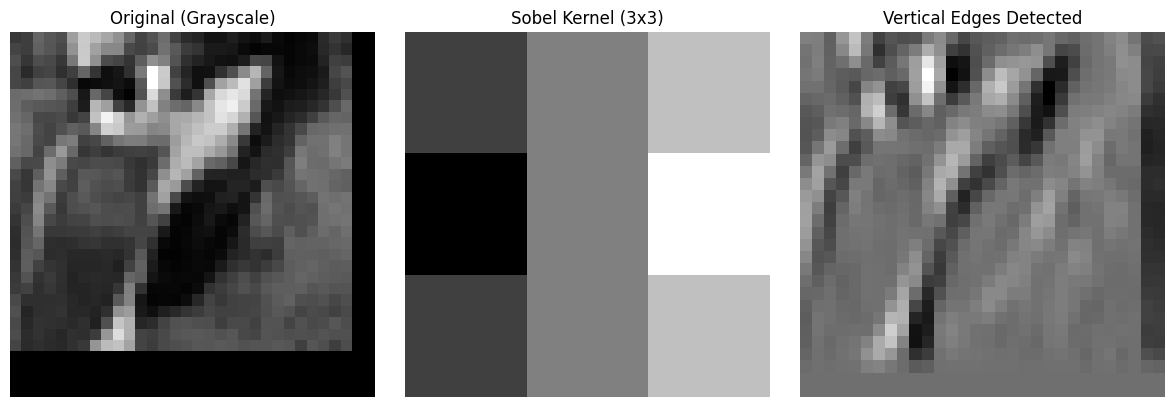

In [ ]:
# Apply the edge detection kernel to an image
# Convert one CIFAR image to grayscale
sample_image = images[0].mean(dim=0, keepdim=True).unsqueeze(0)  # [1, 1, 32, 32]

# Apply convolution
with torch.no_grad():
    edge_detected = conv(sample_image)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sample_image.squeeze().numpy(), cmap='gray')
axes[0].set_title('Original (Grayscale)')
axes[0].axis('off')

axes[1].imshow(sobel_kernel.squeeze().numpy(), cmap='gray')
axes[1].set_title('Sobel Kernel (3x3)')
axes[1].axis('off')

axes[2].imshow(edge_detected.squeeze().numpy(), cmap='gray')
axes[2].set_title('Vertical Edges Detected')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### (ii) Padding and Stride

**Padding**: Adding zeros (or other values) around the input border.
- `padding=0` (valid): Output is smaller than input
- `padding='same'` or appropriate value: Output size equals input size
- Helps preserve spatial dimensions and edge information

**Stride**: The step size when sliding the kernel.
- `stride=1`: Move one pixel at a time (default)
- `stride=2`: Move two pixels at a time (downsamples by factor of 2)

**Output size formula**:
$$\text{Output} = \left\lfloor \frac{\text{Input} + 2 \times \text{padding} - \text{kernel\_size}}{\text{stride}} \right\rfloor + 1$$

Let's visualize how padding and stride affect the convolution:

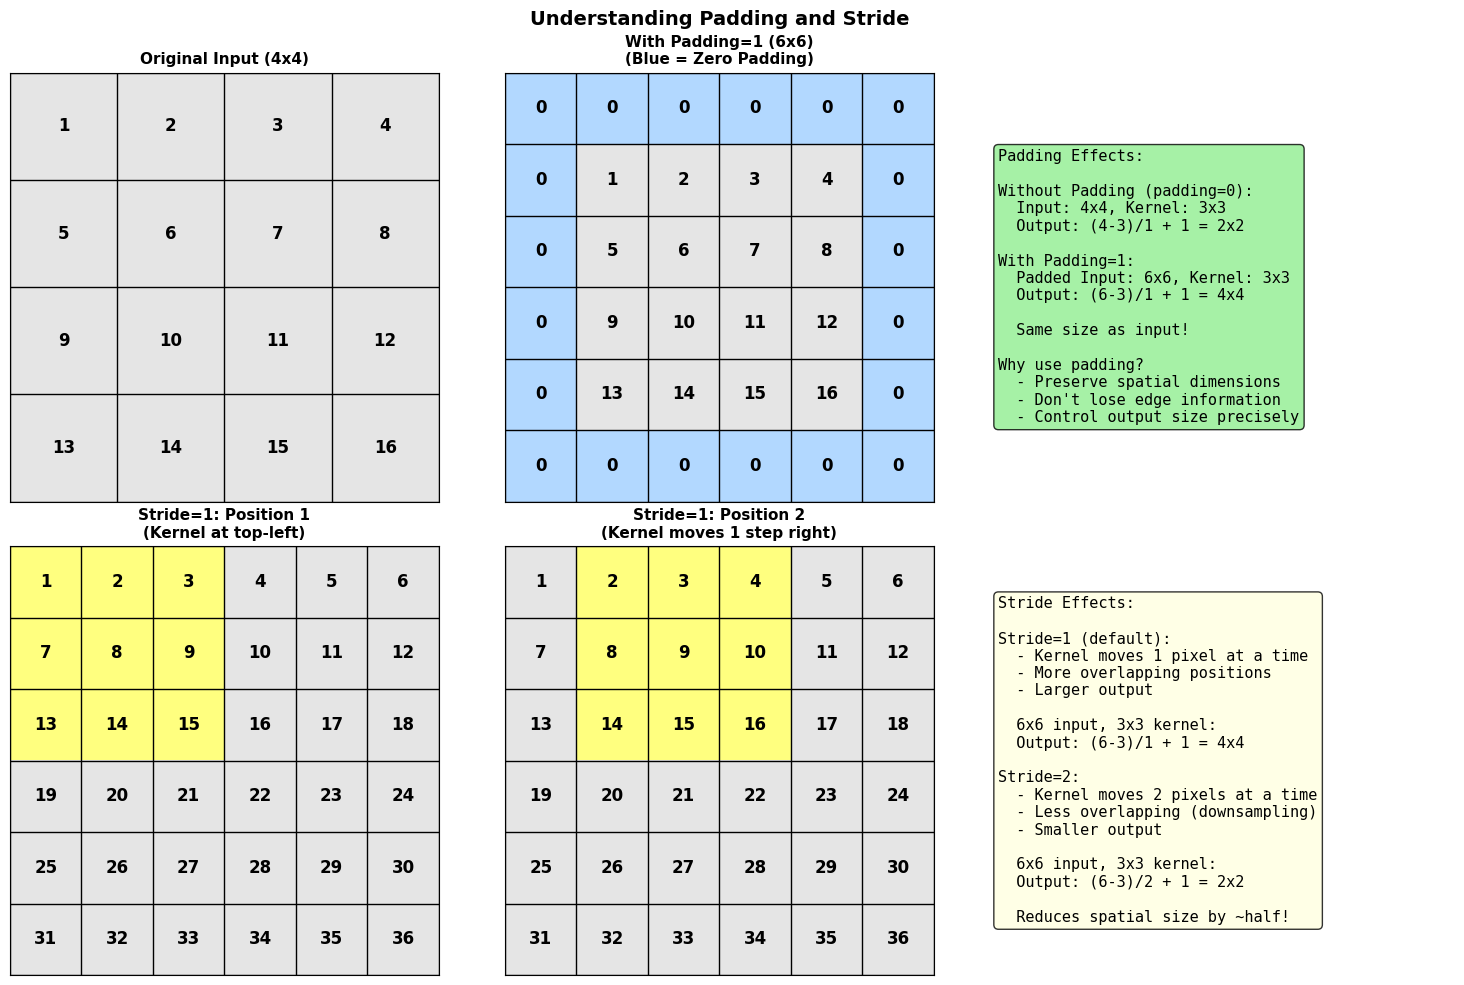

In [ ]:
# Visual Diagram: Padding and Stride Explained

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

def draw_grid(ax, data, title, highlight_cells=None, padding_cells=None):
    """Draw a grid with values and optional highlighting"""
    rows, cols = data.shape

    # Create color map
    colors = np.ones((rows, cols, 3)) * 0.9  # Light gray background

    if padding_cells:
        for (r, c) in padding_cells:
            colors[r, c] = [0.7, 0.85, 1.0]  # Light blue for padding

    if highlight_cells:
        for (r, c) in highlight_cells:
            if 0 <= r < rows and 0 <= c < cols:
                colors[r, c] = [1.0, 1.0, 0.5]  # Yellow for kernel position

    ax.imshow(colors, extent=[-0.5, cols-0.5, rows-0.5, -0.5])

    # Add values
    for i in range(rows):
        for j in range(cols):
            ax.text(j, i, str(int(data[i, j])), ha='center', va='center',
                   fontsize=12, fontweight='bold')

    # Add grid lines
    for i in range(rows + 1):
        ax.axhline(y=i-0.5, color='black', linewidth=1)
    for j in range(cols + 1):
        ax.axvline(x=j-0.5, color='black', linewidth=1)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

# Original 4x4 input
original = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])

# Padded input (padding=1)
padded = np.zeros((6, 6))
padded[1:5, 1:5] = original
padding_positions = [(i, j) for i in range(6) for j in range(6)
                     if i == 0 or i == 5 or j == 0 or j == 5]

# Row 1: Padding visualization
draw_grid(axes[0, 0], original, 'Original Input (4x4)')

draw_grid(axes[0, 1], padded, 'With Padding=1 (6x6)\n(Blue = Zero Padding)',
          padding_cells=padding_positions)

# Show output sizes
axes[0, 2].axis('off')
padding_text = """Padding Effects:

Without Padding (padding=0):
  Input: 4x4, Kernel: 3x3
  Output: (4-3)/1 + 1 = 2x2

With Padding=1:
  Padded Input: 6x6, Kernel: 3x3
  Output: (6-3)/1 + 1 = 4x4

  Same size as input!

Why use padding?
  - Preserve spatial dimensions
  - Don't lose edge information
  - Control output size precisely"""
axes[0, 2].text(0.05, 0.5, padding_text, fontsize=11, va='center', family='monospace',
               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Row 2: Stride visualization
# Create a simple 6x6 input
stride_input = np.arange(1, 37).reshape(6, 6)

# Stride=1: kernel positions
stride1_pos1 = [(i, j) for i in range(3) for j in range(3)]
draw_grid(axes[1, 0], stride_input, 'Stride=1: Position 1\n(Kernel at top-left)',
          highlight_cells=stride1_pos1)

stride1_pos2 = [(i, j) for i in range(3) for j in range(1, 4)]
draw_grid(axes[1, 1], stride_input, 'Stride=1: Position 2\n(Kernel moves 1 step right)',
          highlight_cells=stride1_pos2)

# Stride comparison text
axes[1, 2].axis('off')
stride_text = """Stride Effects:

Stride=1 (default):
  - Kernel moves 1 pixel at a time
  - More overlapping positions
  - Larger output

  6x6 input, 3x3 kernel:
  Output: (6-3)/1 + 1 = 4x4

Stride=2:
  - Kernel moves 2 pixels at a time
  - Less overlapping (downsampling)
  - Smaller output

  6x6 input, 3x3 kernel:
  Output: (6-3)/2 + 1 = 2x2

  Reduces spatial size by ~half!"""
axes[1, 2].text(0.05, 0.5, stride_text, fontsize=11, va='center', family='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Understanding Padding and Stride', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Demonstrate the effect of padding and stride on output dimensions

# Input: 32x32 image with 3 channels
input_tensor = torch.randn(1, 3, 32, 32)

# Different configurations
configs = [
    {'kernel_size': 3, 'stride': 1, 'padding': 0},  # No padding
    {'kernel_size': 3, 'stride': 1, 'padding': 1},  # Same padding
    {'kernel_size': 3, 'stride': 2, 'padding': 1},  # Stride 2 (downsampling)
    {'kernel_size': 5, 'stride': 1, 'padding': 2},  # Larger kernel, same padding
    {'kernel_size': 5, 'stride': 2, 'padding': 2},  # Larger kernel, stride 2
]

print(f"Input shape: {input_tensor.shape}\n")
print(f"{'Kernel':<8} {'Stride':<8} {'Padding':<8} {'Output Shape':<20}")
print("-" * 50)

for cfg in configs:
    conv = nn.Conv2d(in_channels=3, out_channels=16, **cfg)
    output = conv(input_tensor)
    print(f"{cfg['kernel_size']:<8} {cfg['stride']:<8} {cfg['padding']:<8} {str(output.shape):<20}")

Input shape: torch.Size([1, 3, 32, 32])

Kernel   Stride   Padding  Output Shape        
--------------------------------------------------
3        1        0        torch.Size([1, 16, 30, 30])
3        1        1        torch.Size([1, 16, 32, 32])
3        2        1        torch.Size([1, 16, 16, 16])
5        1        2        torch.Size([1, 16, 32, 32])
5        2        2        torch.Size([1, 16, 16, 16])


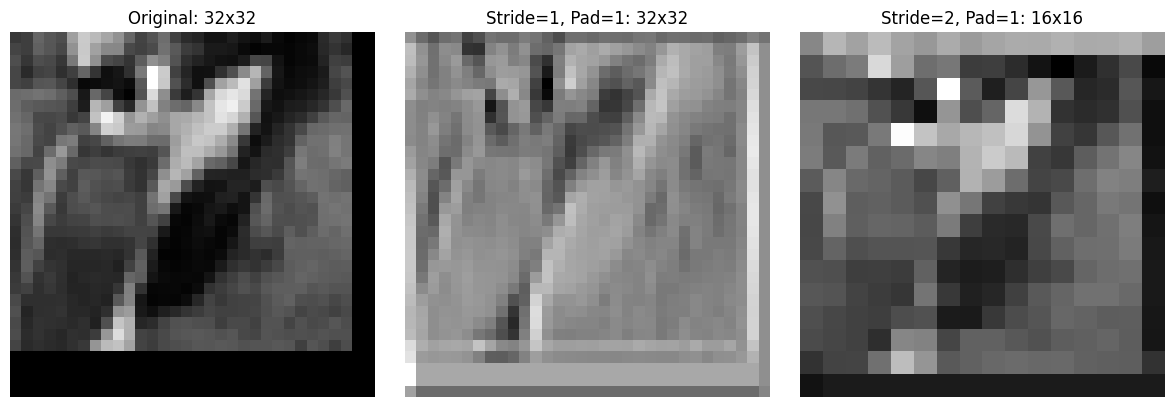

In [ ]:
# Visual demonstration of stride effect
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original
axes[0].imshow(sample_image.squeeze().numpy(), cmap='gray')
axes[0].set_title(f'Original: {sample_image.shape[-2]}x{sample_image.shape[-1]}')
axes[0].axis('off')

# Stride 1
conv_s1 = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1)
out_s1 = conv_s1(sample_image)
axes[1].imshow(out_s1.squeeze().detach().numpy(), cmap='gray')
axes[1].set_title(f'Stride=1, Pad=1: {out_s1.shape[-2]}x{out_s1.shape[-1]}')
axes[1].axis('off')

# Stride 2
conv_s2 = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=1)
out_s2 = conv_s2(sample_image)
axes[2].imshow(out_s2.squeeze().detach().numpy(), cmap='gray')
axes[2].set_title(f'Stride=2, Pad=1: {out_s2.shape[-2]}x{out_s2.shape[-1]}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### (iii) 1x1 Convolution

A **1x1 convolution** (also called a "pointwise convolution") uses a kernel of size 1x1.

**Key uses:**
1. **Channel dimensionality reduction/expansion**: Change the number of channels without changing spatial dimensions
2. **Adding non-linearity**: With activation functions, adds computational depth
3. **Cross-channel feature combination**: Mixes information across channels at each spatial location

**Example**: Reduce 256 channels to 64 channels:
- Regular 3x3 conv: 256 x 64 x 3 x 3 = 147,456 parameters
- 1x1 conv: 256 x 64 x 1 x 1 = 16,384 parameters (90% fewer!)

Let's visualize how 1x1 convolution mixes channels:

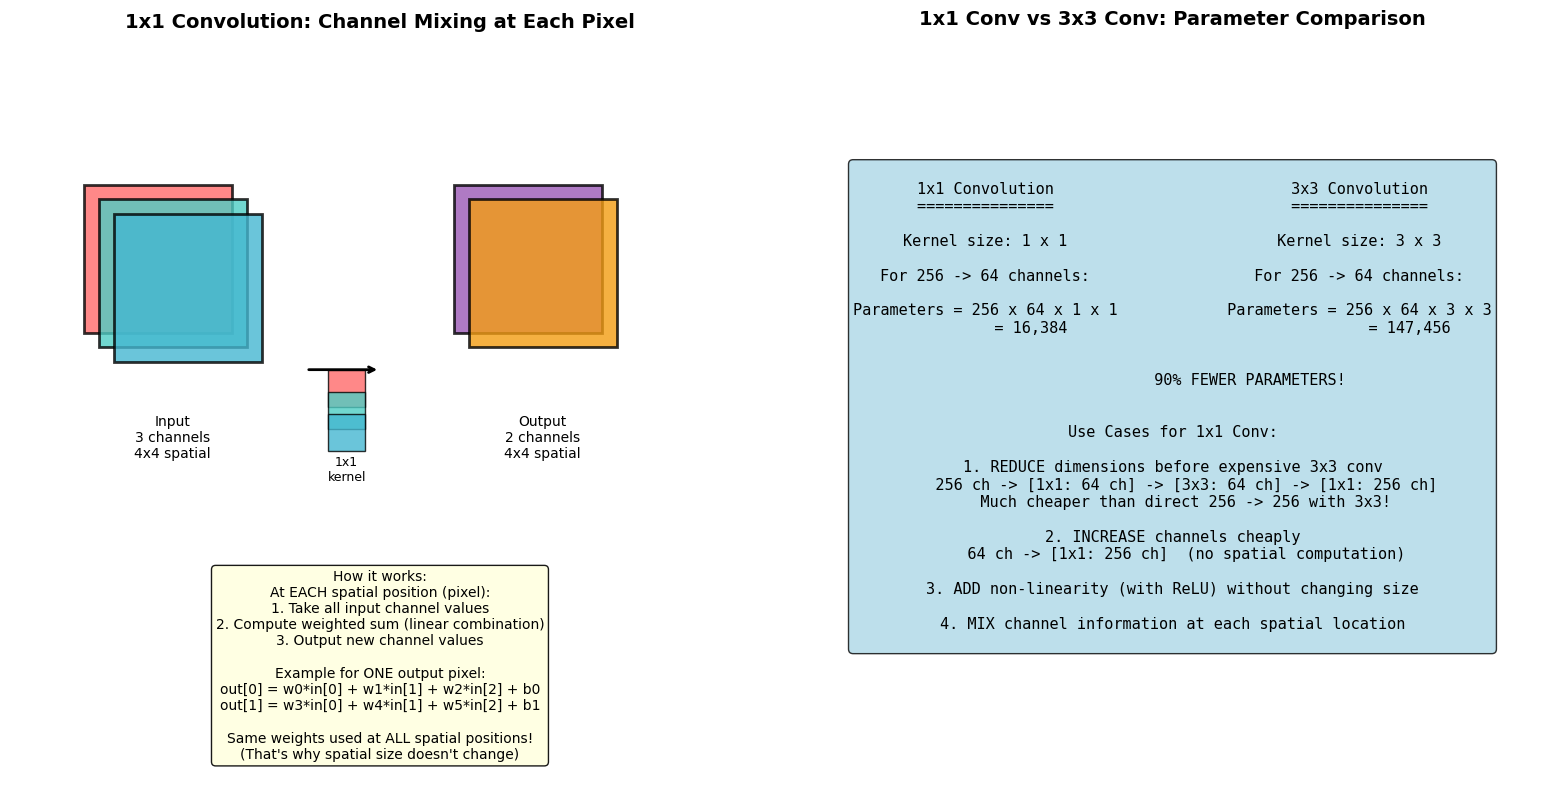

In [ ]:
# Visual Diagram: How 1x1 Convolution Works

fig = plt.figure(figsize=(16, 8))

# Create a diagram showing 1x1 convolution as channel mixing
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('1x1 Convolution: Channel Mixing at Each Pixel', fontsize=14, fontweight='bold')

# Draw input feature maps (3 channels, shown as stacked squares)
colors_in = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Red, Teal, Blue
for i, color in enumerate(colors_in):
    rect = plt.Rectangle((1 + i*0.2, 6 - i*0.2), 2, 2,
                          facecolor=color, edgecolor='black', linewidth=2, alpha=0.8)
    ax1.add_patch(rect)
ax1.text(2.2, 4.3, 'Input\n3 channels\n4x4 spatial', ha='center', fontsize=10)

# Draw arrow
ax1.annotate('', xy=(5, 5.5), xytext=(4, 5.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Draw 1x1 kernel (shown as vertical stack)
for i, color in enumerate(colors_in):
    rect = plt.Rectangle((4.3, 5 - i*0.3), 0.5, 0.5,
                          facecolor=color, edgecolor='black', linewidth=1, alpha=0.8)
    ax1.add_patch(rect)
ax1.text(4.55, 4, '1x1\nkernel', ha='center', fontsize=9)

# Draw output feature maps (2 channels)
colors_out = ['#9B59B6', '#F39C12']  # Purple, Orange
for i, color in enumerate(colors_out):
    rect = plt.Rectangle((6 + i*0.2, 6 - i*0.2), 2, 2,
                          facecolor=color, edgecolor='black', linewidth=2, alpha=0.8)
    ax1.add_patch(rect)
ax1.text(7.2, 4.3, 'Output\n2 channels\n4x4 spatial', ha='center', fontsize=10)

# Add explanation text
explanation = """How it works:
At EACH spatial position (pixel):
1. Take all input channel values
2. Compute weighted sum (linear combination)
3. Output new channel values

Example for ONE output pixel:
out[0] = w0*in[0] + w1*in[1] + w2*in[2] + b0
out[1] = w3*in[0] + w4*in[1] + w5*in[2] + b1

Same weights used at ALL spatial positions!
(That's why spatial size doesn't change)"""
ax1.text(5, 1.5, explanation, fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Second subplot: comparison diagram
ax2 = fig.add_subplot(1, 2, 2)
ax2.axis('off')
ax2.set_title('1x1 Conv vs 3x3 Conv: Parameter Comparison', fontsize=14, fontweight='bold')

comparison_text = """
1x1 Convolution                          3x3 Convolution
===============                          ===============

Kernel size: 1 x 1                       Kernel size: 3 x 3

For 256 -> 64 channels:                  For 256 -> 64 channels:

Parameters = 256 x 64 x 1 x 1            Parameters = 256 x 64 x 3 x 3
           = 16,384                                 = 147,456


                 90% FEWER PARAMETERS!


Use Cases for 1x1 Conv:

1. REDUCE dimensions before expensive 3x3 conv
   256 ch -> [1x1: 64 ch] -> [3x3: 64 ch] -> [1x1: 256 ch]
   Much cheaper than direct 256 -> 256 with 3x3!

2. INCREASE channels cheaply
   64 ch -> [1x1: 256 ch]  (no spatial computation)

3. ADD non-linearity (with ReLU) without changing size

4. MIX channel information at each spatial location
"""
ax2.text(0.5, 0.5, comparison_text, fontsize=11, ha='center', va='center',
        family='monospace', transform=ax2.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
# Demonstrate 1x1 convolution for channel reduction

# Input with many channels
input_many_channels = torch.randn(1, 256, 16, 16)  # 256 channels

# 1x1 convolution to reduce channels
conv_1x1 = nn.Conv2d(
    in_channels=256,
    out_channels=64,
    kernel_size=1,  # This is what makes it a 1x1 conv
    stride=1,
    padding=0
)

output = conv_1x1(input_many_channels)

print(f"Input shape:  {input_many_channels.shape}")
print(f"Output shape: {output.shape}")
print(f"\n1x1 Conv Parameters: {sum(p.numel() for p in conv_1x1.parameters()):,}")

# Compare with 3x3 conv
conv_3x3 = nn.Conv2d(256, 64, kernel_size=3, padding=1)
print(f"3x3 Conv Parameters: {sum(p.numel() for p in conv_3x3.parameters()):,}")

Input shape:  torch.Size([1, 256, 16, 16])
Output shape: torch.Size([1, 64, 16, 16])

1x1 Conv Parameters: 16,448
3x3 Conv Parameters: 147,520


In [ ]:
# 1x1 convolution in a "bottleneck" pattern (used in ResNet)
# Reduce channels -> Apply 3x3 conv -> Expand channels

class BottleneckBlock(nn.Module):
    """Bottleneck block using 1x1 convolutions for efficiency"""
    def __init__(self, in_channels, bottleneck_channels, out_channels):
        super().__init__()

        # 1x1 conv to reduce channels (squeeze)
        self.conv1 = nn.Conv2d(in_channels, bottleneck_channels, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(bottleneck_channels)

        # 3x3 conv (main computation at reduced dimension)
        self.conv2 = nn.Conv2d(bottleneck_channels, bottleneck_channels,
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(bottleneck_channels)

        # 1x1 conv to expand channels (expand)
        self.conv3 = nn.Conv2d(bottleneck_channels, out_channels, kernel_size=1)
        self.bn3 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        return out

# Example: 256 -> 64 -> 256
bottleneck = BottleneckBlock(256, 64, 256)
test_input = torch.randn(1, 256, 16, 16)
test_output = bottleneck(test_input)

print(f"Input:  {test_input.shape}")
print(f"Output: {test_output.shape}")
print(f"Bottleneck parameters: {sum(p.numel() for p in bottleneck.parameters()):,}")

# Compare: direct 3x3 conv from 256 to 256
direct_conv = nn.Sequential(
    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256)
)
print(f"Direct 3x3 parameters: {sum(p.numel() for p in direct_conv.parameters()):,}")

Input:  torch.Size([1, 256, 16, 16])
Output: torch.Size([1, 256, 16, 16])
Bottleneck parameters: 70,784
Direct 3x3 parameters: 590,592


### (iv) Global Average Pooling (GAP)

**Global Average Pooling** computes the average of each feature map (channel) across all spatial locations.

**Input**: [batch, channels, H, W] -> **Output**: [batch, channels, 1, 1]

**Advantages over Fully Connected layers:**
1. **Fewer parameters**: No learned weights (just averaging)
2. **Spatial invariance**: Summarizes "where" a feature appears -> "whether" it appears
3. **No overfitting**: Acts as a structural regularizer
4. **Input size flexibility**: Works with any spatial dimension

**Common usage**: Replace the final FC layers in classification networks.

Let's visualize how GAP collapses spatial dimensions:

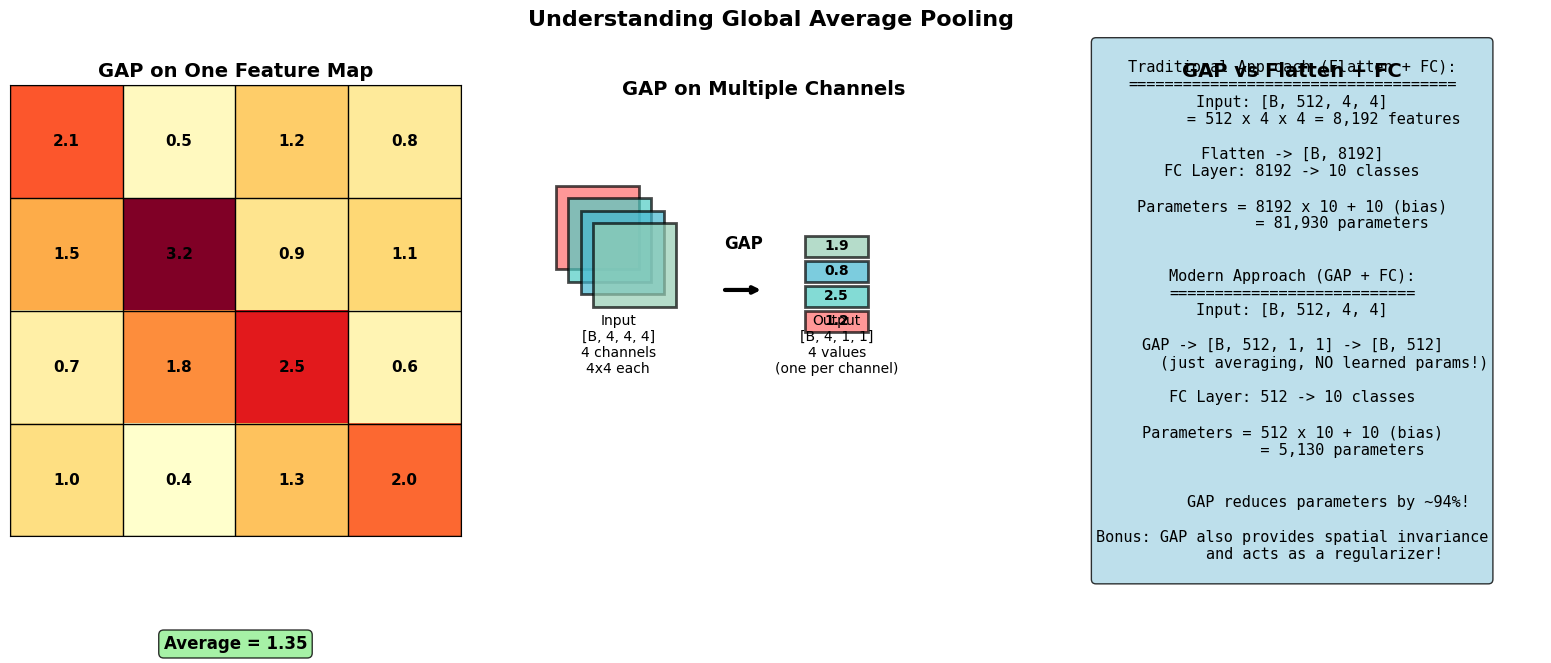

In [ ]:
# Visual Diagram: Global Average Pooling Explained

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Left panel: Show GAP operation on a single channel
ax1 = axes[0]
ax1.set_title('GAP on One Feature Map', fontsize=14, fontweight='bold')

# Create a 4x4 feature map
feature_map = np.array([
    [2.1, 0.5, 1.2, 0.8],
    [1.5, 3.2, 0.9, 1.1],
    [0.7, 1.8, 2.5, 0.6],
    [1.0, 0.4, 1.3, 2.0]
])

# Draw the feature map
im = ax1.imshow(feature_map, cmap='YlOrRd', extent=[-0.5, 3.5, 3.5, -0.5])
for i in range(4):
    for j in range(4):
        ax1.text(j, i, f'{feature_map[i,j]:.1f}', ha='center', va='center',
                fontsize=11, fontweight='bold')
for line in range(5):
    ax1.axhline(y=line-0.5, color='black', linewidth=1)
    ax1.axvline(x=line-0.5, color='black', linewidth=1)
ax1.set_xticks([])
ax1.set_yticks([])

# Add calculation
gap_result = feature_map.mean()
ax1.text(1.5, 4.5, f'Average = {gap_result:.2f}', ha='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Middle panel: Show multi-channel GAP
ax2 = axes[1]
ax2.set_xlim(0, 12)
ax2.set_ylim(0, 10)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('GAP on Multiple Channels', fontsize=14, fontweight='bold')

# Draw input feature maps (stacked)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
channel_values = [1.2, 2.5, 0.8, 1.9]  # Average values per channel

for i, (color, val) in enumerate(zip(colors, channel_values)):
    # Input feature map (4x4)
    rect = plt.Rectangle((1 + i*0.3, 6 - i*0.3), 2, 2,
                          facecolor=color, edgecolor='black', linewidth=2, alpha=0.7)
    ax2.add_patch(rect)

ax2.text(2.5, 3.5, 'Input\n[B, 4, 4, 4]\n4 channels\n4x4 each', ha='center', fontsize=10)

# Arrow
ax2.annotate('', xy=(6, 5.5), xytext=(5, 5.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='black'))
ax2.text(5.5, 6.5, 'GAP', ha='center', fontsize=12, fontweight='bold')

# Output (single values per channel, shown as vertical bar)
for i, (color, val) in enumerate(zip(colors, channel_values)):
    rect = plt.Rectangle((7, 4.5 + i*0.6), 1.5, 0.5,
                          facecolor=color, edgecolor='black', linewidth=2, alpha=0.7)
    ax2.add_patch(rect)
    ax2.text(7.75, 4.75 + i*0.6, f'{val}', ha='center', va='center', fontsize=10, fontweight='bold')

ax2.text(7.75, 3.5, 'Output\n[B, 4, 1, 1]\n4 values\n(one per channel)', ha='center', fontsize=10)

# Right panel: Comparison with FC layer
ax3 = axes[2]
ax3.axis('off')
ax3.set_title('GAP vs Flatten + FC', fontsize=14, fontweight='bold')

comparison = """
Traditional Approach (Flatten + FC):
====================================
Input: [B, 512, 4, 4]
       = 512 x 4 x 4 = 8,192 features

Flatten -> [B, 8192]
FC Layer: 8192 -> 10 classes

Parameters = 8192 x 10 + 10 (bias)
           = 81,930 parameters


Modern Approach (GAP + FC):
===========================
Input: [B, 512, 4, 4]

GAP -> [B, 512, 1, 1] -> [B, 512]
       (just averaging, NO learned params!)

FC Layer: 512 -> 10 classes

Parameters = 512 x 10 + 10 (bias)
           = 5,130 parameters


        GAP reduces parameters by ~94%!

Bonus: GAP also provides spatial invariance
       and acts as a regularizer!
"""

ax3.text(0.5, 0.5, comparison, ha='center', va='center', fontsize=11,
        family='monospace', transform=ax3.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.suptitle('Understanding Global Average Pooling', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Demonstrate Global Average Pooling

# Feature maps from a CNN (e.g., 512 channels, 4x4 spatial)
feature_maps = torch.randn(1, 512, 4, 4)

# Global Average Pooling
gap = nn.AdaptiveAvgPool2d(1)  # Output size: 1x1
pooled = gap(feature_maps)

print(f"Input shape:  {feature_maps.shape}")
print(f"After GAP:    {pooled.shape}")
print(f"Squeezed:     {pooled.squeeze().shape}")

# Verify: GAP computes mean over spatial dimensions
manual_gap = feature_maps.mean(dim=[2, 3], keepdim=True)
print(f"\nManual GAP matches: {torch.allclose(pooled, manual_gap)}")

Input shape:  torch.Size([1, 512, 4, 4])
After GAP:    torch.Size([1, 512, 1, 1])
Squeezed:     torch.Size([512])

Manual GAP matches: True


In [ ]:
# Compare parameters: GAP vs Fully Connected

# Assume we have 512 feature maps of size 4x4 and want 10 class outputs

# Method 1: Flatten + FC (traditional approach)
fc_layer = nn.Linear(512 * 4 * 4, 10)  # Flatten all features
print(f"Flatten + FC parameters: {sum(p.numel() for p in fc_layer.parameters()):,}")

# Method 2: GAP + FC (modern approach)
gap_fc = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(512, 10)
)
print(f"GAP + FC parameters: {sum(p.numel() for p in gap_fc.parameters()):,}")

# Test both
test_features = torch.randn(1, 512, 4, 4)
print(f"\nFC output: {fc_layer(test_features.flatten(1)).shape}")
print(f"GAP+FC output: {gap_fc(test_features).shape}")

Flatten + FC parameters: 81,930
GAP + FC parameters: 5,130

FC output: torch.Size([1, 10])
GAP+FC output: torch.Size([1, 10])


---
## 3. Building the CNN Model

Now let's build a complete CNN that incorporates all these concepts:
- Convolutional layers with learned kernels
- Proper padding to maintain dimensions
- Stride for downsampling
- 1x1 convolutions for channel manipulation
- Global Average Pooling before classification

In [ ]:
class SimpleCNN(nn.Module):
    """
    A simple CNN for CIFAR-10 classification demonstrating:
    - Kernels: 3x3 convolutions throughout
    - Padding: padding=1 to maintain spatial dimensions
    - Stride: downsampling now uses 1x1 conv + average pooling
    - 1x1 Conv: For channel adjustment
    - GAP: Global Average Pooling before classifier
    """
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Input image is (N, 3, 32, 32)
        # Block 1: 32x32x3 -> 32x32x32
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # (N,32,32,32)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # (N,32,32,32)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        # Output after block1: (N,32,32,32)

        # Downsample 1: 32x32x32 -> 16x16x64 (1x1 conv, then avg pool)
        self.downsample1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=1),       # (N,64,32,32)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),  # (N,64,16,16)
        )
        # Output after downsample1: (N,64,16,16)

        # Block 2: 16x16x64 -> 16x16x64
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  # (N,64,16,16)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  # (N,64,16,16)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        # Output after block2: (N,64,16,16)

        # Downsample 2: 16x16x64 -> 8x8x128 (1x1 conv, then avg pool)
        self.downsample2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1),      # (N,128,16,16)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),  # (N,128,8,8)
        )
        # Output after downsample2: (N,128,8,8)

        # Block 3 with 1x1 convolution: 8x8x128 -> 8x8x128
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),  # (N,128,8,8)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # 1x1 convolution for cross-channel interaction
            nn.Conv2d(128, 128, kernel_size=1),  # 1x1 conv! (N,128,8,8)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        # Output after block3: (N,128,8,8)

        # Downsample 3: 8x8x128 -> 4x4x256 (1x1 conv, then avg pool)
        self.downsample3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=1),     # (N,256,8,8)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),  # (N,256,4,4)
        )
        # Output after downsample3: (N,256,4,4)

        # Final block with 1x1 conv: 4x4x256 -> 4x4x256
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),  # (N,256,4,4)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # 1x1 convolution
            nn.Conv2d(256, 256, kernel_size=1),  # 1x1 conv! (N,256,4,4)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        # Output after block4: (N,256,4,4)

        # Global Average Pooling: 4x4x256 -> 1x1x256
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)  # (N,256,1,1)

        # Classifier: 256 -> num_classes
        self.classifier = nn.Linear(256, num_classes)    # (N,num_classes)

    def forward(self, x):
        # Feature extraction
        x = self.block1(x)       # (N, 32, 32, 32)
        x = self.downsample1(x)  # (N, 64, 16, 16)
        x = self.block2(x)       # (N, 64, 16, 16)
        x = self.downsample2(x)  # (N, 128, 8, 8)
        x = self.block3(x)       # (N, 128, 8, 8)
        x = self.downsample3(x)  # (N, 256, 4, 4)
        x = self.block4(x)       # (N, 256, 4, 4)

        # Global Average Pooling
        x = self.global_avg_pool(x)  # (N, 256, 1, 1)
        x = x.view(x.size(0), -1)    # (N, 256)

        # Classification
        x = self.classifier(x)       # (N, num_classes)

        return x

In [ ]:
# Create model and inspect
model = SimpleCNN(num_classes=10).to(device)

# Print model architecture
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (downsample1): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (block2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64

In [ ]:
# Verify model with a forward pass
test_input = torch.randn(2, 3, 32, 32).to(device)
test_output = model(test_input)
print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {test_output.shape}")

Input shape:  torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 10])


---
## 4. Training Loop

Now we'll train the model with:
- Cross-entropy loss for classification
- Adam optimizer with learning rate scheduling
- Training and validation monitoring

In [ ]:
# Training configuration
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2#, verbose=True
)

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [ ]:
def evaluate(model, test_loader, criterion, device):
    """Evaluate the model on test set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [ ]:
# Training loop
train_losses = []
train_accs = []
test_losses = []
test_accs = []

print("Starting training...")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Test Loss':<12} {'Test Acc':<12}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    # Update scheduler
    scheduler.step(test_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {test_loss:<12.4f} {test_acc:<12.2f}")

print("\nTraining complete!")

Starting training...
Epoch    Train Loss   Train Acc    Test Loss    Test Acc    
------------------------------------------------------------
1        1.3330       51.64        1.1971       58.31       
2        0.9372       66.72        0.9840       64.91       
3        0.7713       72.88        1.1323       64.20       
4        0.6559       77.20        0.7220       75.66       
5        0.5745       80.09        0.6032       79.17       
6        0.5160       82.11        0.6700       77.78       
7        0.4768       83.48        0.5864       80.53       
8        0.4441       84.56        0.6650       78.04       
9        0.4132       85.52        0.4982       83.34       
10       0.3877       86.58        0.5508       82.24       

Training complete!


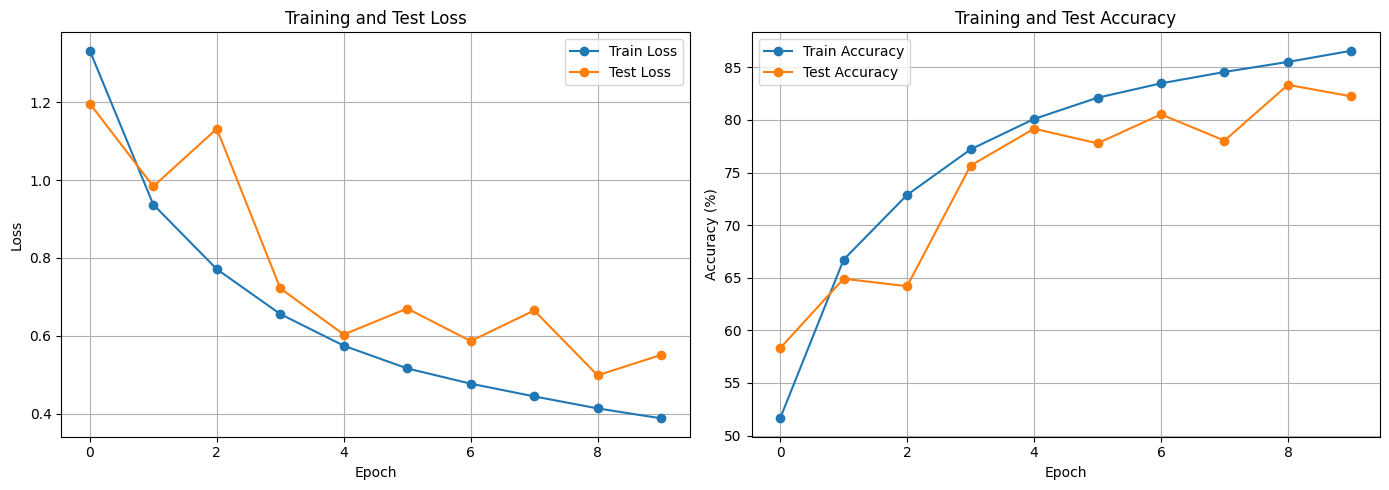

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(test_losses, label='Test Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy', marker='o')
axes[1].plot(test_accs, label='Test Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## 5. Evaluation and Visualization

In [ ]:
# Per-class accuracy
def evaluate_per_class(model, test_loader, device, classes):
    """Calculate accuracy for each class"""
    model.eval()
    class_correct = [0] * len(classes)
    class_total = [0] * len(classes)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            for i in range(len(labels)):
                label = labels[i].item()
                class_total[label] += 1
                if predicted[i] == label:
                    class_correct[label] += 1

    return class_correct, class_total

class_correct, class_total = evaluate_per_class(model, test_loader, device, classes)

print("Per-class accuracy:")
print("-" * 35)
for i, class_name in enumerate(classes):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{class_name:<12}: {acc:>6.2f}% ({class_correct[i]}/{class_total[i]})")

Per-class accuracy:
-----------------------------------
airplane    :  71.90% (719/1000)
automobile  :  88.90% (889/1000)
bird        :  67.70% (677/1000)
cat         :  64.70% (647/1000)
deer        :  84.40% (844/1000)
dog         :  85.60% (856/1000)
frog        :  93.70% (937/1000)
horse       :  82.70% (827/1000)
ship        :  87.80% (878/1000)
truck       :  95.00% (950/1000)


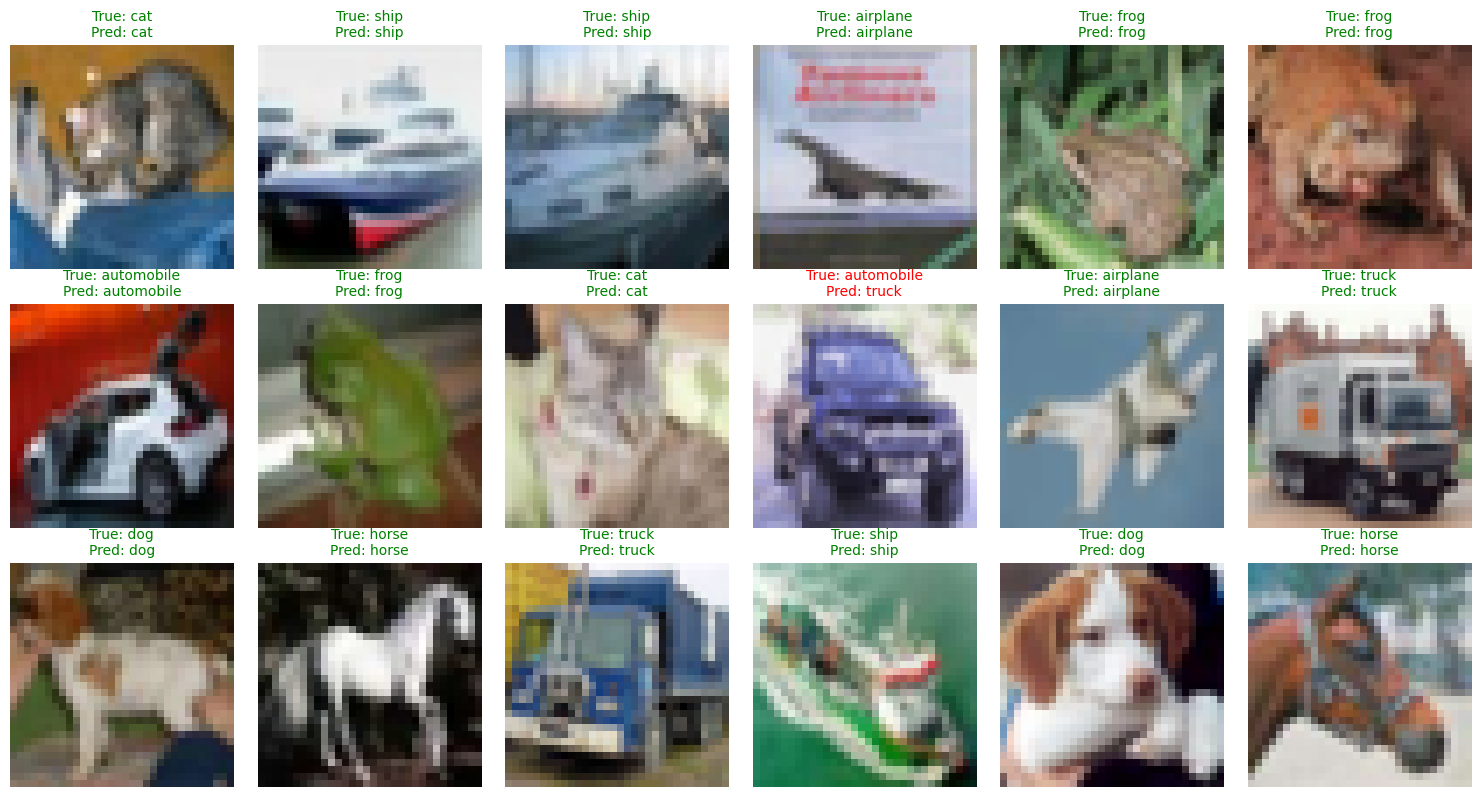

In [ ]:
# Visualize some predictions
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)

# Show predictions
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    # Unnormalize image
    img = images[i].cpu().numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = std[:, None, None] * img + mean[:, None, None]
    img = np.clip(img, 0, 1)

    ax.imshow(np.transpose(img, (1, 2, 0)))

    true_label = classes[labels[i]]
    pred_label = classes[predicted[i]]
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

First conv layer filter shape: torch.Size([32, 3, 3, 3])


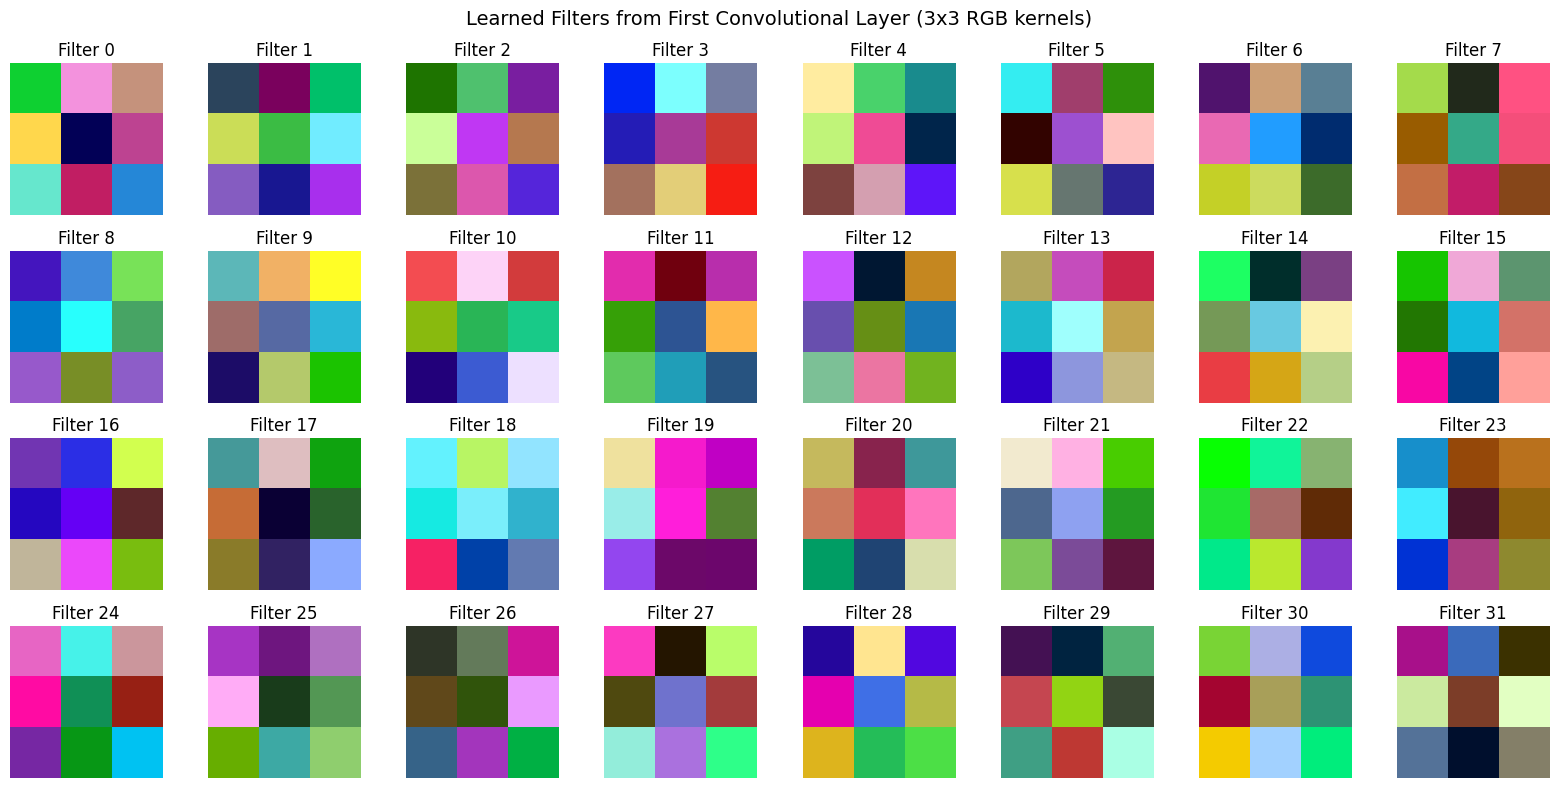

In [ ]:
# Visualize learned filters from the first convolutional layer
# Get the first conv layer's weights
first_conv_weights = model.block1[0].weight.data.cpu()
print(f"First conv layer filter shape: {first_conv_weights.shape}")
# Shape: [out_channels, in_channels, H, W] = [32, 3, 3, 3]

# Visualize the 32 filters (each is 3x3x3 for RGB input)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < 32:
        # Get filter and normalize for visualization
        filt = first_conv_weights[i].numpy()
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
        ax.imshow(np.transpose(filt, (1, 2, 0)))
        ax.set_title(f'Filter {i}')
    ax.axis('off')

plt.suptitle('Learned Filters from First Convolutional Layer (3x3 RGB kernels)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Summary

In this notebook, we covered the complete CNN training pipeline for CIFAR-10:

### Key Concepts Demonstrated:

| Concept | Description | Usage in Our Model |
|---------|-------------|-------------------|
| **Kernels** | Small learnable filters that detect features | 3x3 kernels throughout the network |
| **Padding** | Zeros added around input to control output size | `padding=1` to maintain spatial dimensions |
| **Stride** | Step size when sliding the kernel | `stride=2` for downsampling (32→16→8→4) |
| **1x1 Conv** | Pointwise convolution for channel mixing | Used in block3 and block4 for feature recombination |
| **Global Average Pooling** | Average each channel over all spatial locations | Replaces flatten+FC, reduces parameters significantly |

### Training Pipeline:
1. **Data Loading**: CIFAR-10 with transforms and DataLoader
2. **Model Definition**: CNN with all key components
3. **Training Loop**: Forward pass → Loss → Backward pass → Update
4. **Evaluation**: Per-class accuracy and visualizations